# Figure 1 — Hiring rises after the deal, and the response is concentrated in targets with low pre-deal hiring intensity

Every number is read from an aggregate result artifact in `../artifacts/` — the files the submitted manuscript's tables were generated from.
No licensed microdata is used or required (see `../DATA_ACCESS.md`). Outputs are stored, so the notebook renders on GitHub without running.
The code below is cut verbatim from the paper's figure builder; the last cell checks the regenerated PNG against the image embedded in the submitted .docx.


## Setup


In [ ]:
import json, os, csv, io
import numpy as np
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
ART, EX = "../artifacts", "."
J = lambda f: json.load(open(os.path.join(ART, f + ".json"), encoding="utf-8"))
L = {r["claim_id"]: r for r in csv.DictReader(open(os.path.join(ART, "CLAIMS_LEDGER.csv"), encoding="utf-8-sig"))}
c = lambda cid, w="value": L[cid][w]
_figs = []
def SAVE(fig, n):
    for e in ("png", "pdf"): fig.savefig(f"{EX}/{n}.{e}", dpi=200, bbox_inches="tight")
    b = io.BytesIO(); fig.savefig(b, format="png", dpi=110, bbox_inches="tight"); _figs.append(b.getvalue())


## Build


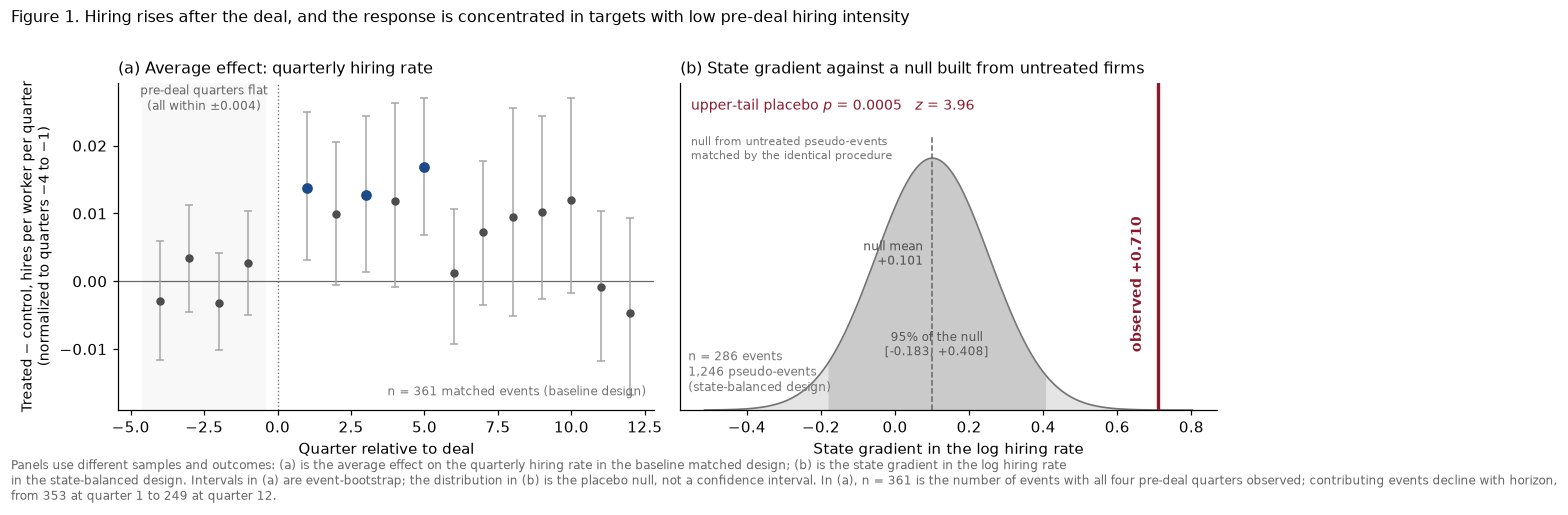

saved figure1_event_study.png / .pdf


In [ ]:

# ════════════ Figure 2 — 이벤트스터디 + 조절/위약 ════════════
i32, i33, i35, i31, i68 = J("I32"), J("I33"), J("I35"), J("I31"), J("I68")
B = i68["estimates"]["beta"]
QL = [f"q{k}" for k in range(-4, 0)] + [f"q{k}" for k in range(1, 13)]
xs = list(range(-4, 0)) + list(range(1, 13))
b = [B[q]["b"] for q in QL]; lo = [B[q]["ci"][0] for q in QL]; hi = [B[q]["ci"][1] for q in QL]
sig = [B[q]["sig"] for q in QL]
SB = i35["estimates"]["canonical"]["C1_samebin"]; PL = i31["estimates"]["panelA_conditional_placebo"]
fig, ax = plt.subplots(1, 2, figsize=(11.2, 4.2))
a0 = ax[0]
a0.axhline(0, color="0.4", lw=.8); a0.axvline(0, color="0.45", lw=.9, ls=":")
a0.axvspan(-4.6, -0.4, color="0.5", alpha=.05, lw=0, zorder=0)
a0.errorbar(xs, b, yerr=[np.array(b)-np.array(lo), np.array(hi)-np.array(b)], fmt="o", ms=4.5,
            lw=1, capsize=2.5, color="0.3", ecolor="0.65", zorder=3)
a0.scatter([x for x, s in zip(xs, sig) if s], [v for v, s in zip(b, sig) if s], s=36,
           color="#1b4a8a", zorder=5)
a0.annotate("pre-deal quarters flat\n(all within ±0.004)", xy=(-2.5, max(hi[:4]) * 1.9 + 0.004),
            fontsize=8, color="0.4", ha="center")
a0.set_title("(a) Average effect: quarterly hiring rate", fontsize=10.5, loc="left")
a0.set_ylabel("Treated − control, hires per worker per quarter\n(normalized to quarters −4 to −1)", fontsize=9)
a0.set_xlabel("Quarter relative to deal")
a0.text(.985, .045, f"n = {i68['estimates']['n_ev']} matched events (baseline design)",
        transform=a0.transAxes, ha="right", fontsize=8, color="0.45")
a1 = ax[1]
i53 = J("I60")["estimates"]["specs"]["winsor_5_95"]
# 귀무분포를 정규 근사로 그린다 — draw 원자료는 저장하지 않으므로 평균·SD·95% 범위로 재구성
mu, sd = i53["null_mean"], i53["null_sd"]
lo, hi = i53["null_ci"]
xs = np.linspace(mu - 4 * sd, max(mu + 4 * sd, i53["observed"] + 0.6 * sd), 400)
dens = np.exp(-0.5 * ((xs - mu) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))
a1.fill_between(xs, dens, color="0.55", alpha=.22, lw=0, zorder=0)
a1.plot(xs, dens, color="0.45", lw=1.1, zorder=1)
inb = (xs >= lo) & (xs <= hi)
a1.fill_between(xs[inb], dens[inb], color="0.55", alpha=.30, lw=0, zorder=1)
a1.axvline(mu, color="0.4", lw=1, ls="--", zorder=2, ymax=.84)
a1.axvline(i53["observed"], color="#8a1b2e", lw=2.2, zorder=4)
ytop = dens.max()
a1.annotate(f"observed {i53['observed']:+.3f}", xy=(i53["observed"], ytop * .50),
            xytext=(-9, 0), textcoords="offset points", fontsize=9.4, color="#8a1b2e",
            weight="bold", va="center", ha="right", rotation=90)
a1.annotate(f"null mean\n{mu:+.3f}", xy=(mu, ytop * .62), xytext=(-6, 0),
            textcoords="offset points", fontsize=7.8, color="0.3", ha="right", va="center")
a1.annotate(f"95% of the null\n[{lo:+.3f}, {hi:+.3f}]", xy=((lo + hi) / 2, ytop * .26),
            fontsize=7.8, color="0.35", ha="center", va="center")
a1.text(.02, .95, f"upper-tail placebo $p$ = {i53['RI_p']:.4f}   $z$ = {i53['z']}",
        transform=a1.transAxes, ha="left", va="top", fontsize=9.2, color="#8a1b2e")
a1.text(.02, .84, "null from untreated pseudo-events\nmatched by the identical procedure",
        transform=a1.transAxes, ha="left", va="top", fontsize=7.4, color="0.45")
a1.set_yticks([])
a1.set_xlabel("State gradient in the log hiring rate")
a1.set_title("(b) State gradient against a null built from untreated firms",
             fontsize=10.5, loc="left")
a1.text(.015, .045, "n = 286 events\n1,246 pseudo-events\n(state-balanced design)",
        transform=a1.transAxes, ha="left", va="bottom", fontsize=8, color="0.45")
a1.set_ylim(0, ytop * 1.30)
for a in ax: a.spines[["top", "right"]].set_visible(False)
fig.suptitle("Figure 1. Hiring rises after the deal, and the response is concentrated in targets "
             "with low pre-deal hiring intensity", fontsize=10.2, y=1.005, x=.008, ha="left")
fig.text(.008, -0.055, "Panels use different samples and outcomes: (a) is the average effect on the "
         "quarterly hiring rate in the baseline matched design; (b) is the state gradient in the "
         "log hiring rate\nin the state-balanced design. Intervals in (a) are event-bootstrap; "
         "the distribution in (b) is the placebo null, not a confidence interval. "
         f"In (a), n = {i68['estimates']['n_ev']} is the number of events with all four pre-deal quarters observed; "
         f"contributing events decline with horizon,\nfrom {i68['estimates']['beta']['q1']['n']} at quarter 1 to "
         f"{i68['estimates']['beta']['q12']['n']} at quarter 12.",
         fontsize=7.6, color="0.4", ha="left")
fig.tight_layout(); SAVE(fig, "figure1_event_study"); plt.close(fig); print("saved figure1_event_study.png / .pdf")


## Check


In [ ]:
import hashlib
a = hashlib.sha256(open("figure1_event_study.png", "rb").read()).hexdigest()
b = hashlib.sha256(open("../paper_exhibits/figure1_event_study.png", "rb").read()).hexdigest()
print("regenerated PNG sha256 ==", "image embedded in the submitted .docx" if a == b else "DIFFERS", a[:16]); assert a == b


regenerated PNG sha256 == image embedded in the submitted .docx a936d4f9b939ab87
